# Heart Disease Dataset  -  Exploratory Data Analysis

Heart disease is one of the leading causes of death worldwide, and catching it early makes a real difference. This dataset comes from Kaggle and was actually combined from five separate medical datasets (Cleveland, Hungarian, Switzerland, Long Beach VA, and Stalog). The final version has 918 patient records total.

The point of this notebook is to explore the data before doing anything else, figure out what we're working with, spot any problems, and get a feel for which features might actually matter for predicting heart disease.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [30]:
df = pd.read_csv('heart.csv')

print(f'Shape: {df.shape}')
print()
print(df.dtypes)

Shape: (918, 12)

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object


In [31]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


## Understanding the Features

Before doing anything with the data, it helps to know what each column actually means. Some are obvious, some need a little context.

| Feature | What it is |
|---|---|
| **Age** | Patient age in years |
| **Sex** | M = Male, F = Female |
| **ChestPainType** | Type of chest pain: ATA (Atypical Angina), NAP (Non-Anginal Pain), ASY (Asymptomatic), TA (Typical Angina) |
| **RestingBP** | Resting blood pressure in mm Hg |
| **Cholesterol** | Serum cholesterol in mg/dL |
| **FastingBS** | Fasting blood sugar: 1 if above 120 mg/dL, 0 otherwise |
| **RestingECG** | Resting ECG results: Normal, ST (wave abnormality), LVH (enlarged heart muscle) |
| **MaxHR** | Highest heart rate recorded during exercise |
| **ExerciseAngina** | Did exercise cause chest pain? Y or N |
| **Oldpeak** | A measurement from ECG showing how much the ST segment drops during exercise compared to rest. Higher values generally mean the heart is struggling more under stress |
| **ST_Slope** | The shape of the ST segment during peak exercise: Up, Flat, or Down |
| **HeartDisease** | Target variable: 1 = heart disease, 0 = no heart disease |

One thing worth knowing upfront: the ECG-related features (Oldpeak, ST_Slope, RestingECG) are all about how the heart's electrical activity looks, either at rest or during exercise. You don't need to fully understand the cardiology to analyse them, but it's good to know they're measuring stress on the heart rather than something structural.

Also, asymptomatic chest pain (ASY) sounds like it should be the least worrying type since the patient isn't really feeling classic symptoms, but it actually turns out to be the most dangerous category in this dataset. Worth keeping in mind.

## Missing Data and Data Quality

First thing to check is whether there are any nulls.

In [50]:
df.isnull().sum()

Age                   0
Sex                   0
ChestPainType         0
RestingBP             0
Cholesterol           0
FastingBS             0
RestingECG            0
MaxHR                 0
ExerciseAngina        0
Oldpeak               0
ST_Slope              0
HeartDisease          0
chol_missing          0
HeartDisease_label    0
dtype: int64

No nulls at all. But the data isn't necessarily clean just because there are no NaN values. Let's look at the actual numbers.

In [51]:
df.describe().round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,chol_missing
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55,0.19
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50,0.39
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00,0.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00,0.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00,1.00


A couple of things immediately look off:

- **RestingBP has a minimum of 0**  -  blood pressure of zero isn't possible in a living patient, so this is clearly a recording error somewhere
- **Cholesterol also has a minimum of 0**  -  same issue, cholesterol can't actually be zero. These rows probably had missing values that got filled with 0 instead of being left blank
- **Oldpeak goes down to -2.6**  -  slightly negative values can technically happen depending on how the measurement is taken, but it's worth flagging

In [52]:
print('Rows with Cholesterol == 0:', (df['Cholesterol'] == 0).sum())
print('Rows with RestingBP == 0:', (df['RestingBP'] == 0).sum())
print('Rows with Oldpeak < 0:', (df['Oldpeak'] < 0).sum())

Rows with Cholesterol == 0: 172
Rows with RestingBP == 0: 1
Rows with Oldpeak < 0: 13


So 172 out of 918 rows have Cholesterol recorded as 0, which is about 19% of the whole dataset. That's a lot. These aren't real cholesterol readings, they're basically hidden missing values.

For now we're keeping them in but flagging them. Before any modeling these would need to be dealt with properly (replacing them with the median value, grouped by something like age or sex, would probably be the most sensible approach).

The one RestingBP = 0 is almost certainly a typo. The negative Oldpeak values we'll leave since they're technically within an acceptable range.

In [53]:
df['chol_missing'] = (df['Cholesterol'] == 0).astype(int)

print('Heart disease rate when cholesterol IS recorded:')
print(df[df['chol_missing'] == 0]['HeartDisease'].mean().round(3))
print()
print('Heart disease rate when cholesterol is missing (= 0):')
print(df[df['chol_missing'] == 1]['HeartDisease'].mean().round(3))

Heart disease rate when cholesterol IS recorded:
0.477

Heart disease rate when cholesterol is missing (= 0):
0.884


That's actually interesting. The group with missing cholesterol data has a noticeably higher heart disease rate than the group where cholesterol was properly recorded. So the missingness isn't random, it seems like patients with heart disease were more likely to have this value missing or recorded differently. Something to keep in mind.

## Target Variable

Let's see how balanced the dataset is between sick and healthy patients.

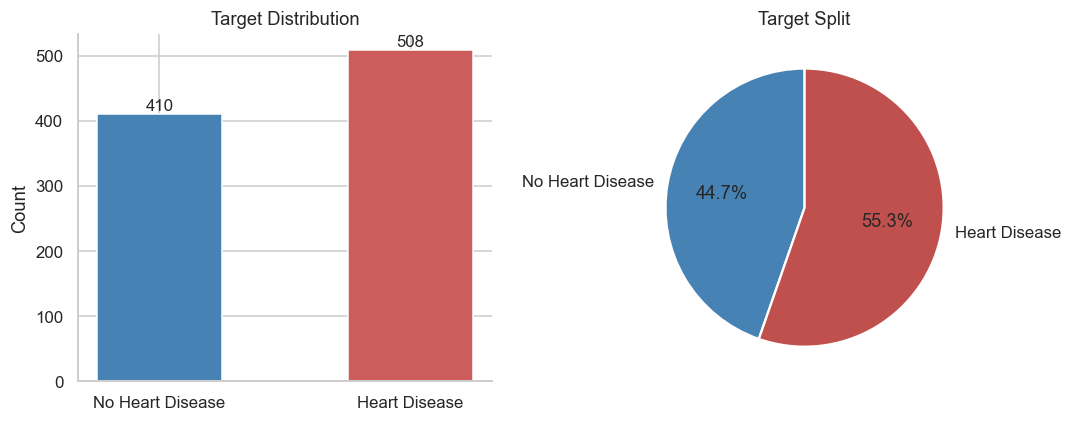

In [54]:
counts = df['HeartDisease'].value_counts()
labels = ['No Heart Disease', 'Heart Disease']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, [counts[0], counts[1]], color=['steelblue', 'indianred'], width=0.5, edgecolor='white')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

axes[1].pie([counts[0], counts[1]], labels=labels, colors=['steelblue', '#C0504D'],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Target Split')

plt.tight_layout()
plt.show()

508 patients with heart disease (55.3%) vs 410 without (44.7%). Slightly more cases than non-cases but not a big imbalance. This is actually pretty decent for a medical dataset, we won't need to do anything special to handle it.

## Univariate Analysis  -  Numeric Features

Looking at the distributions of the numeric columns first, before comparing them against the target.

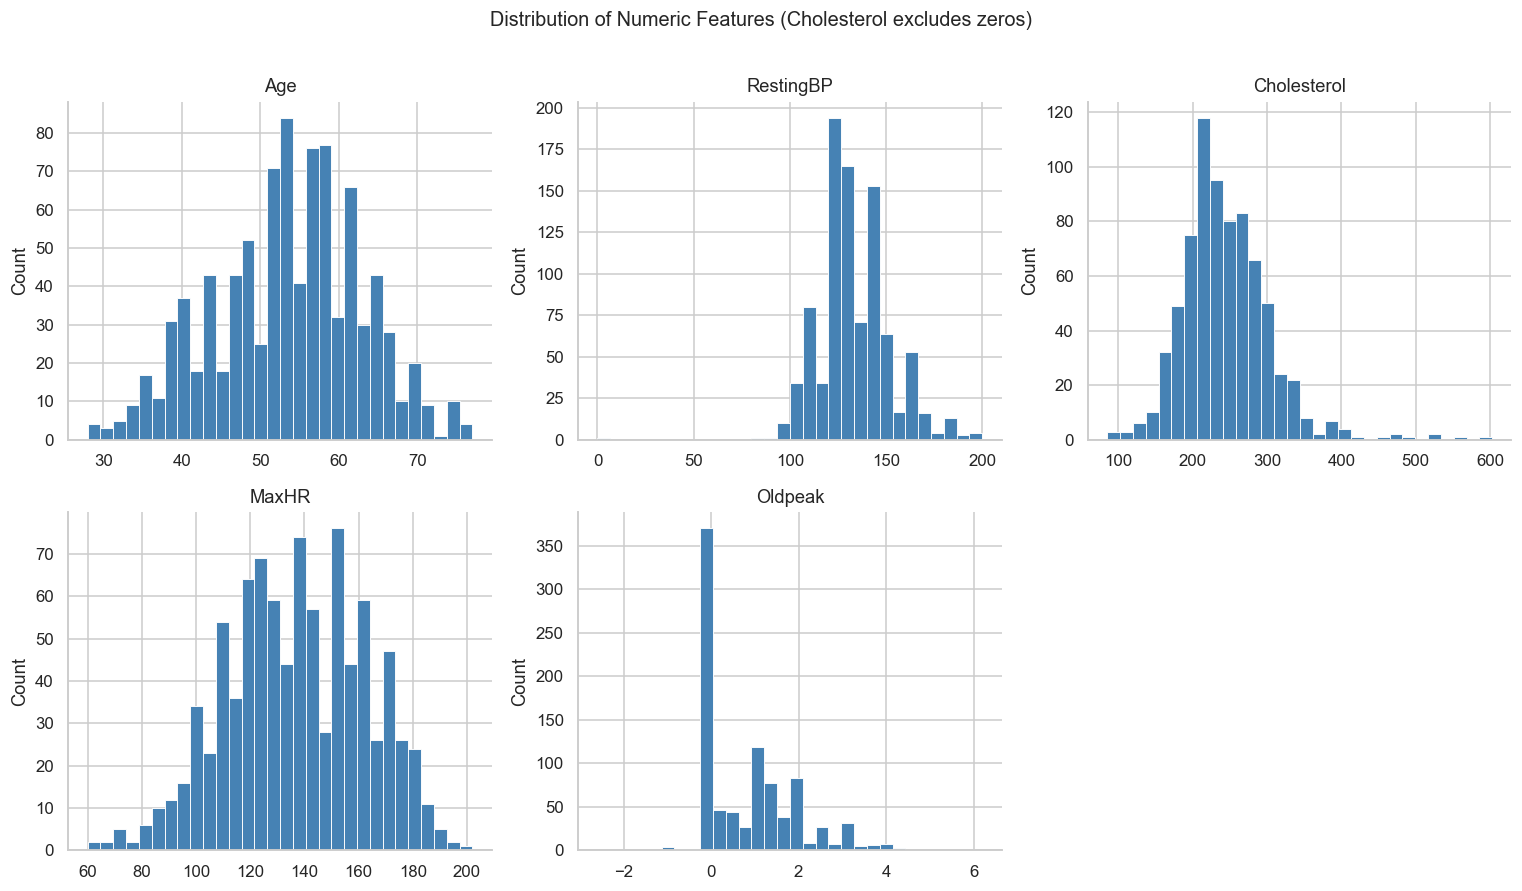

In [55]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col] if col != 'Cholesterol' else df[df['Cholesterol'] > 0]['Cholesterol']
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.6)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

axes[5].set_visible(False)

fig.suptitle('Distribution of Numeric Features (Cholesterol excludes zeros)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

A few things to note here:

- **Age** is roughly bell-shaped, most patients are between 45 and 65, which makes sense for a heart disease study
- **RestingBP** looks fairly normal but has a tail on the right side, some patients are in the 180-200 range which is quite high
- **Cholesterol** (zeros excluded) is skewed to the right, with a few very high values above 500. Anything above around 400 is considered seriously elevated
- **MaxHR** is skewed left, most people hit somewhere in the 120-170 range during exercise
- **Oldpeak** is very skewed, most values are near zero but some patients show a lot of ST depression during exercise

## Univariate Analysis  -  Categorical Features

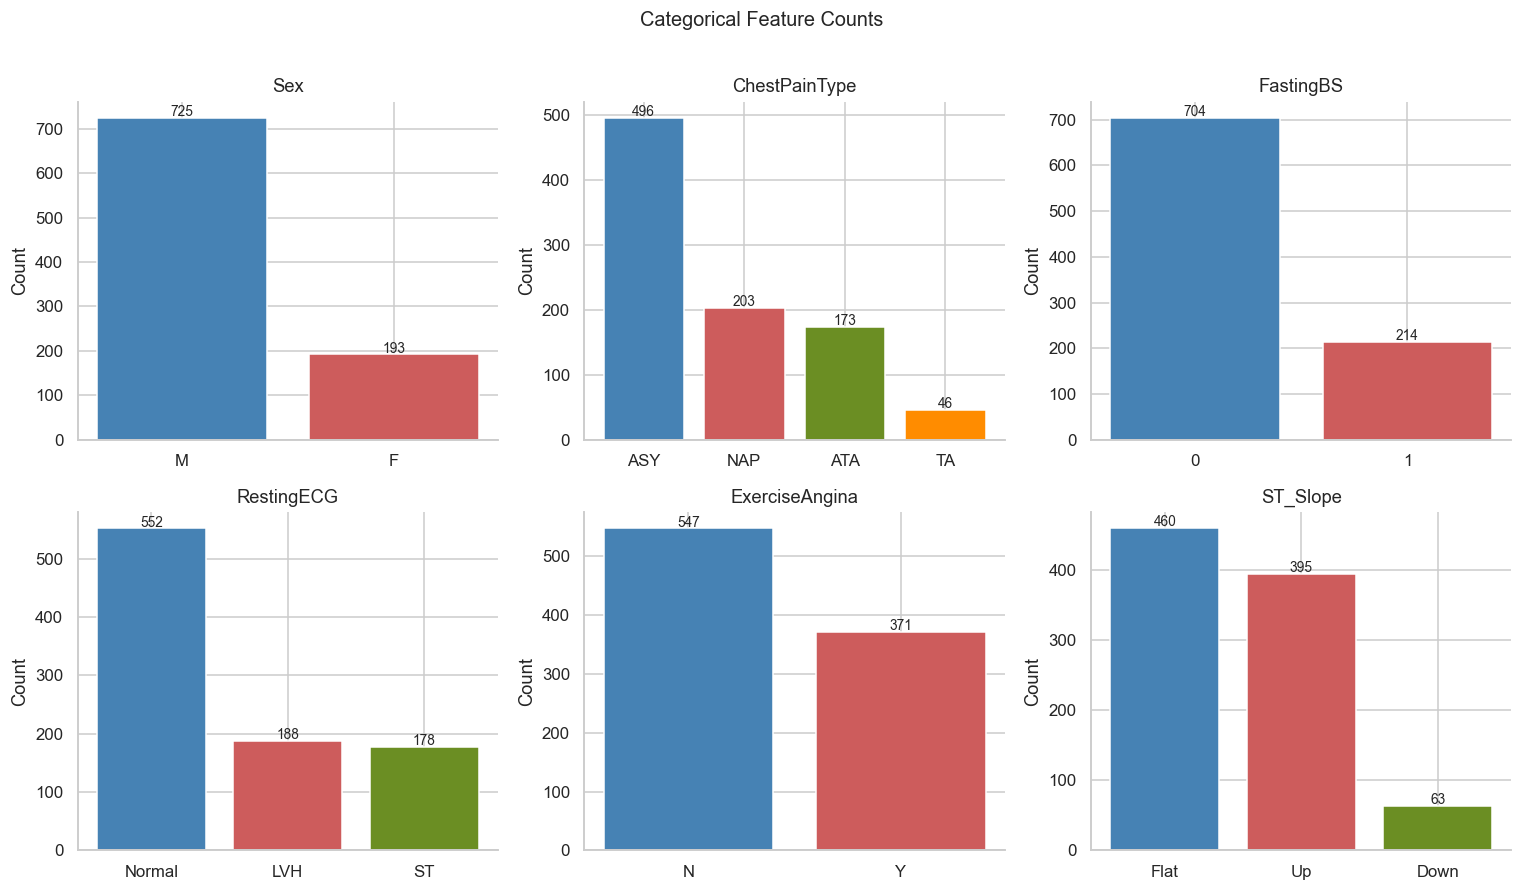

In [56]:
cat_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
cat_labels = {
    'FastingBS': {0: 'Normal', 1: '> 120 mg/dL'}
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

colors = ['steelblue', 'indianred', 'olivedrab', 'darkorange']

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index.astype(str), vc.values, color=colors[:len(vc)], edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 3, str(v), ha='center', fontsize=9)

fig.suptitle('Categorical Feature Counts', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The most obvious thing here is the gender imbalance: 725 men vs 193 women. This is pretty common in older cardiology studies since clinical trials historically enrolled more male patients. It means any comparisons between male and female patients should be read carefully.

Asymptomatic chest pain (ASY) is the most common chest pain type by quite a bit. Most patients have a normal resting ECG. Only about 23% have elevated fasting blood sugar.

## Feature vs Heart Disease  -  Numeric Variables

Now comparing each numeric feature between patients with and without heart disease.

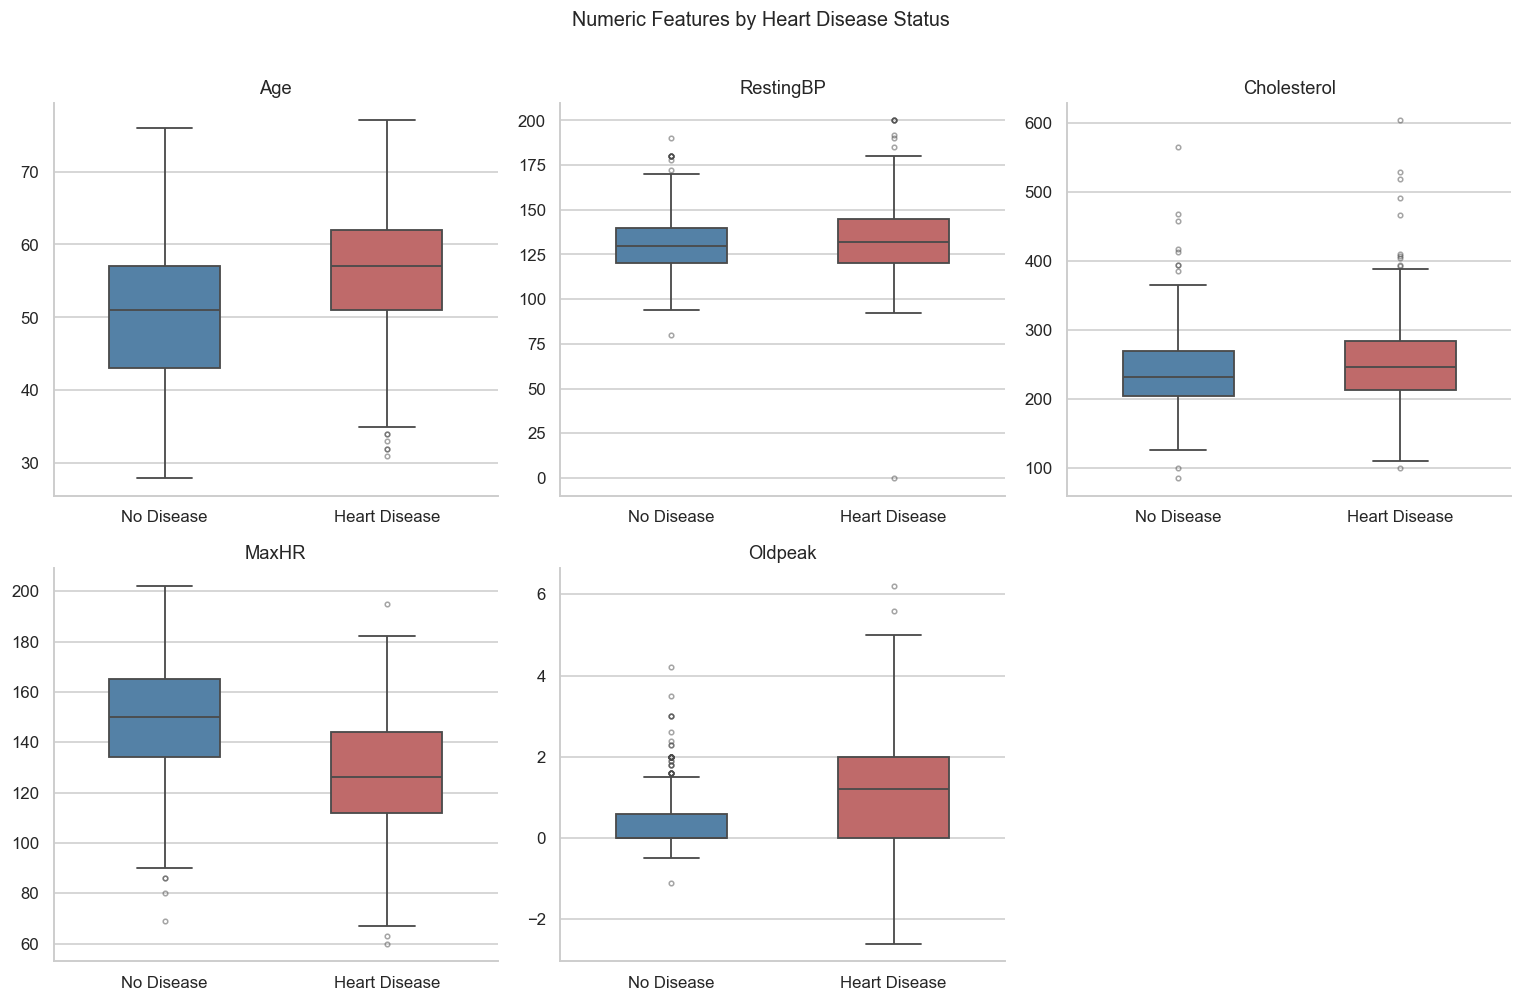

In [57]:
df['HeartDisease_label'] = df['HeartDisease'].map({0: 'No Disease', 1: 'Heart Disease'})

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

palette = {'No Disease': 'steelblue', 'Heart Disease': 'indianred'}

for i, col in enumerate(num_cols):
    plot_df = df.copy()
    if col == 'Cholesterol':
        plot_df = df[df['Cholesterol'] > 0].copy()
    sns.boxplot(data=plot_df, x='HeartDisease_label', y=col,
                palette=palette, ax=axes[i], width=0.5, linewidth=1.2,
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[5].set_visible(False)
fig.suptitle('Numeric Features by Heart Disease Status', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Some clear patterns here:

- **Age**: patients with heart disease are older on average, around 56 vs 51. Not a huge gap but consistent
- **MaxHR**: this one stands out a lot. Patients with heart disease reach a noticeably lower max heart rate during exercise, medians are about 20 bpm apart. A heart that's struggling tends to not be able to push as hard
- **Oldpeak**: higher in the disease group, which makes sense since more ST depression during exercise is a sign of the heart being under strain
- **RestingBP**: there's a small difference but honestly not that useful on its own as a separator
- **Cholesterol** (non-zero only): this one is actually counterintuitive. The healthy group has higher cholesterol on average. One possible explanation is that patients who already know they have heart disease are often put on cholesterol-lowering medication (statins), which would bring their numbers down artificially

## Feature vs Heart Disease  -  Categorical Variables

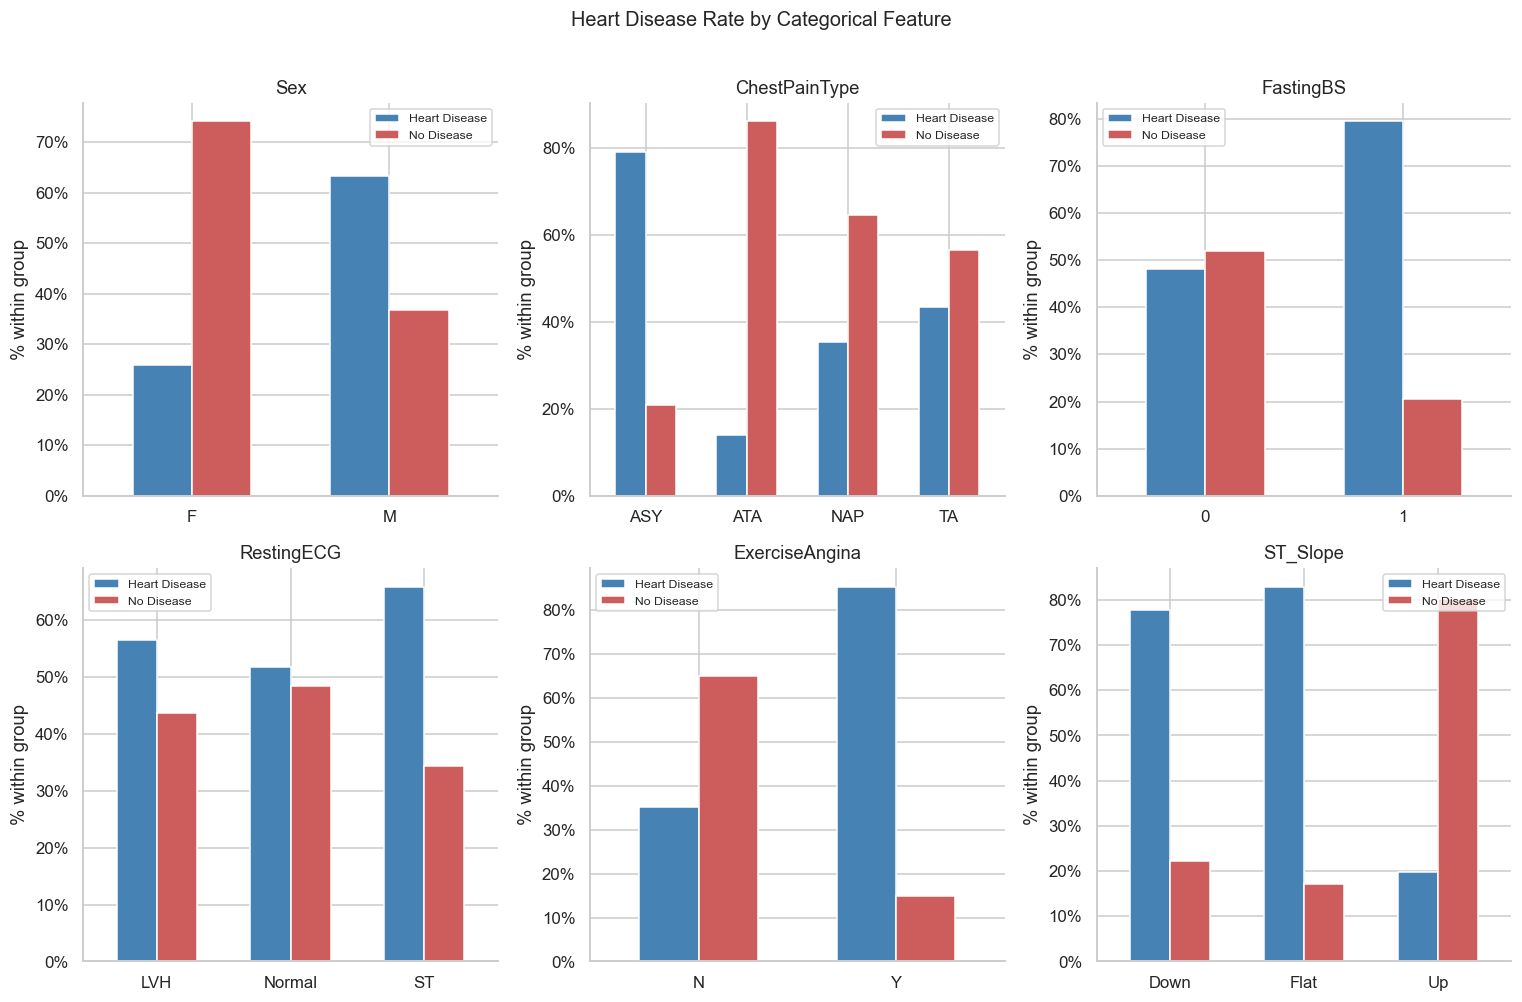

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['HeartDisease_label'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'indianred'],
            edgecolor='white', width=0.6, rot=0)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% within group')
    axes[i].legend(title='', fontsize=8)
    axes[i].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f%%'))

fig.suptitle('Heart Disease Rate by Categorical Feature', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Really clear signals in these:

- **Sex**: around 63% of male patients in this dataset have heart disease vs only 26% of female patients. But again, there are way more men in the dataset so this needs to be read carefully, it doesn't mean women are less at risk generally
- **ChestPainType**: ASY patients have a ~79% heart disease rate, which is the highest of any chest pain type. Meanwhile ATA (atypical angina) patients are mostly healthy (~14% disease rate). So the "typical" looking chest pain is actually less of a red flag than no pain at all
- **ExerciseAngina**: if exercise causes chest pain, about 85% of those patients have heart disease. Very strong signal
- **ST_Slope**: flat or downward sloping ST segments are strongly linked to disease (83% and 78% respectively). Upward slope is mostly healthy, only about 20% disease rate
- **FastingBS**: high fasting blood sugar has a somewhat higher disease rate, which lines up with diabetes being a known heart risk factor
- **RestingECG**: LVH and ST abnormalities both show more disease than normal ECG, but the gap isn't as dramatic as some other features

## Correlation Analysis

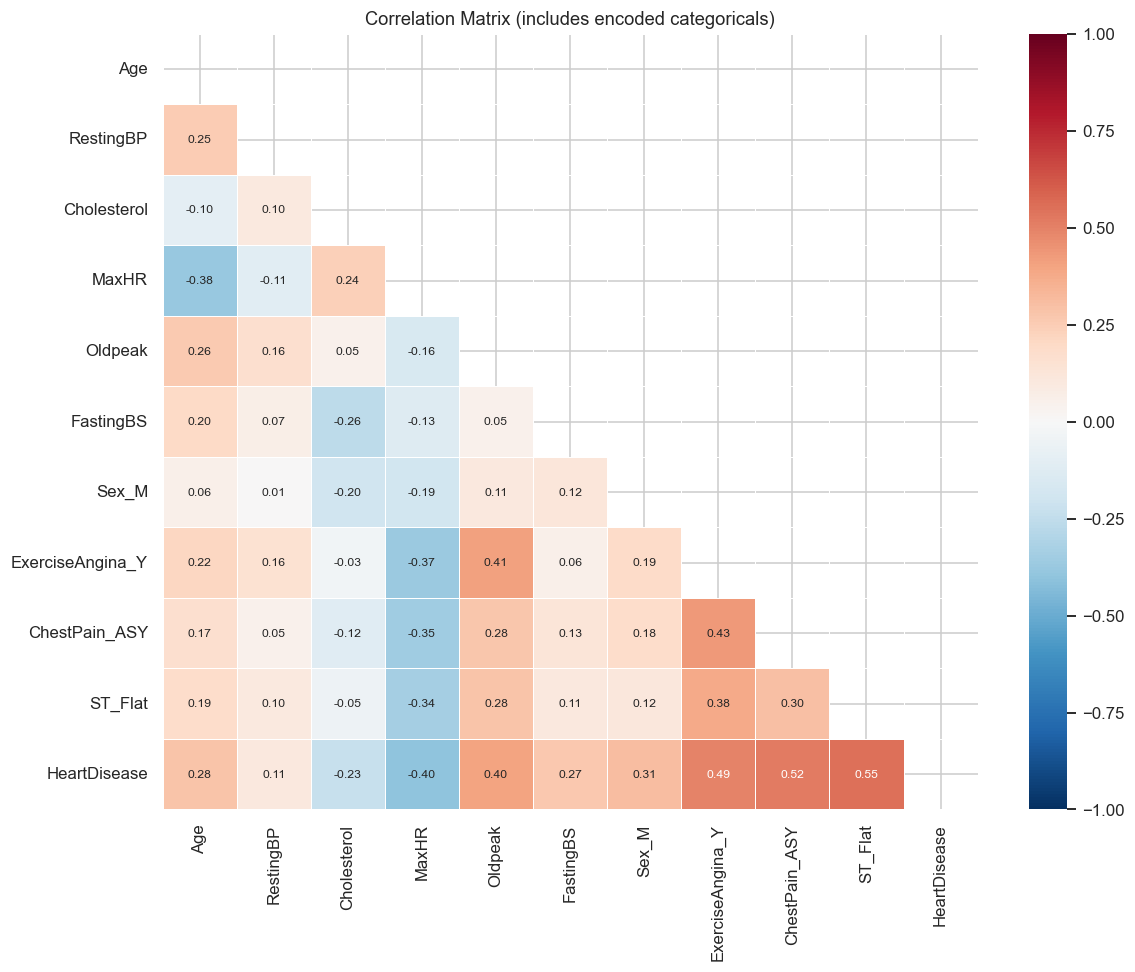

In [59]:
encoded = df.copy()
encoded['Sex_M'] = (df['Sex'] == 'M').astype(int)
encoded['ExerciseAngina_Y'] = (df['ExerciseAngina'] == 'Y').astype(int)
encoded['ChestPain_ASY'] = (df['ChestPainType'] == 'ASY').astype(int)
encoded['ST_Flat'] = (df['ST_Slope'] == 'Flat').astype(int)

corr_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
             'FastingBS', 'Sex_M', 'ExerciseAngina_Y', 'ChestPain_ASY', 'ST_Flat', 'HeartDisease']

corr = encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlation Matrix (includes encoded categoricals)', fontsize=12)
plt.tight_layout()
plt.show()

Focusing on the HeartDisease row: ExerciseAngina, ST_Flat, ChestPain_ASY, and being male all correlate positively with the target. MaxHR has a negative correlation, meaning higher max heart rate is associated with lower disease likelihood. Oldpeak and Age also lean positive.

There's also a decent negative correlation between Age and MaxHR, which makes sense since older people naturally can't push their heart rate as high during exercise.

## Multivariate  -  Age, MaxHR and Disease Status

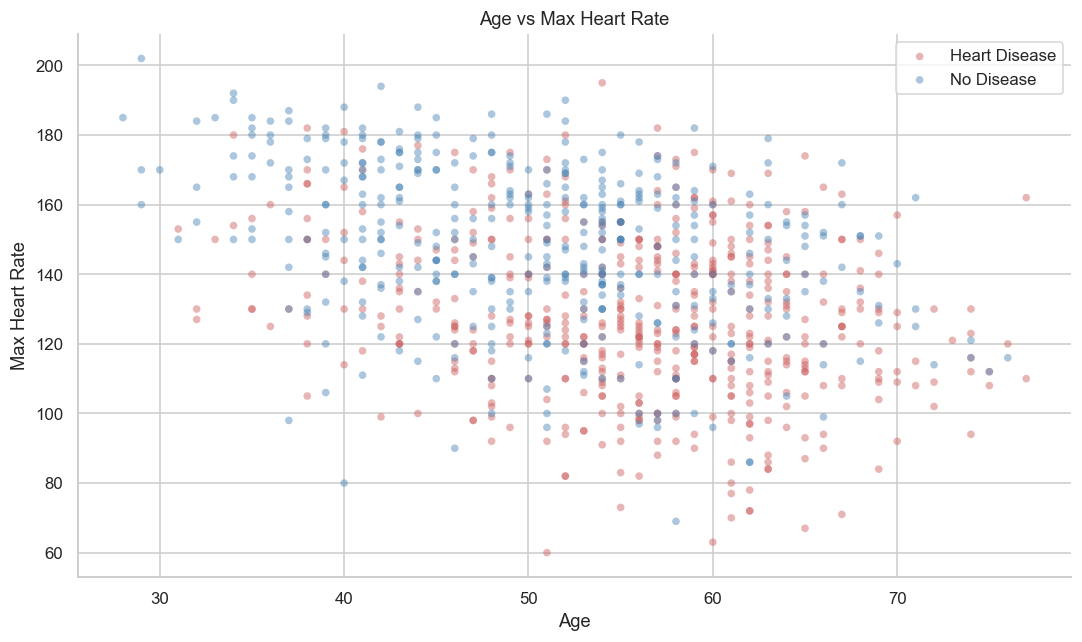

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, grp in df.groupby('HeartDisease_label'):
    color = 'indianred' if label == 'Heart Disease' else 'steelblue'
    ax.scatter(grp['Age'], grp['MaxHR'], alpha=0.45, s=25,
               color=color, label=label, edgecolors='none')

ax.set_xlabel('Age')
ax.set_ylabel('Max Heart Rate')
ax.set_title('Age vs Max Heart Rate')
ax.legend()
plt.tight_layout()
plt.show()

You can see the pattern pretty clearly here. The red dots (heart disease) cluster toward older ages with lower max heart rates, while the blue dots (no disease) are more spread out and tend to sit higher up on the y-axis. The groups do overlap in the middle, but the general trend is there.

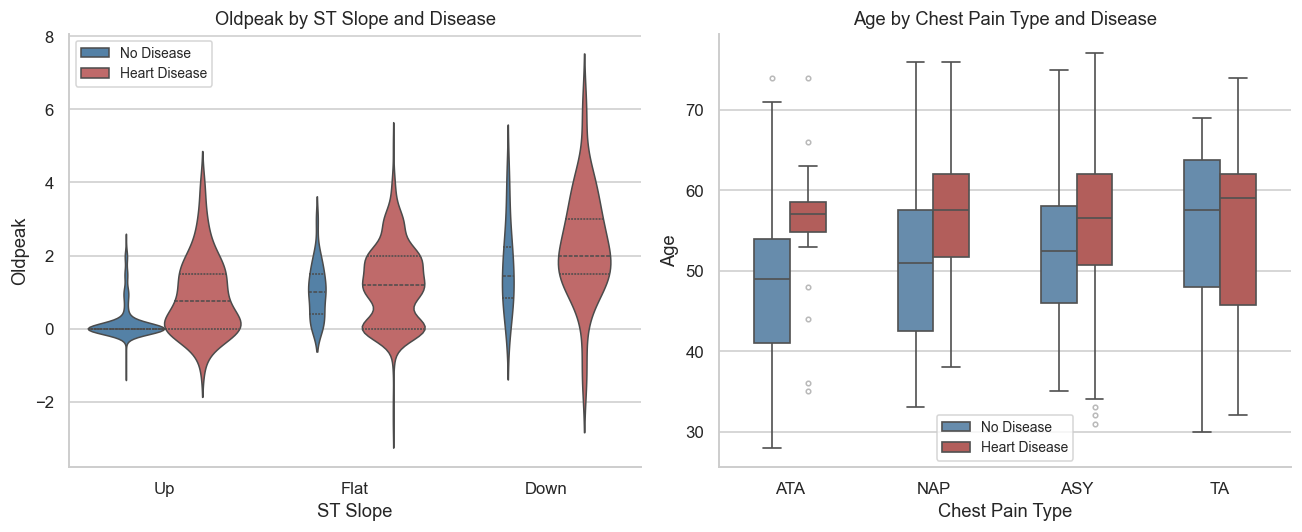

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(data=df, x='ST_Slope', y='Oldpeak', hue='HeartDisease_label',
               palette={'No Disease': 'steelblue', 'Heart Disease': 'indianred'},
               split=False, inner='quartile', ax=axes[0], linewidth=1)
axes[0].set_title('Oldpeak by ST Slope and Disease')
axes[0].set_xlabel('ST Slope')
axes[0].legend(title='', fontsize=9)

sns.boxplot(data=df, x='ChestPainType', y='Age',
            hue='HeartDisease_label',
            palette={'No Disease': '#5B8DB8', 'Heart Disease': '#C0504D'},
            ax=axes[1], width=0.5, linewidth=1.1,
            flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
axes[1].set_title('Age by Chest Pain Type and Disease')
axes[1].set_xlabel('Chest Pain Type')
axes[1].legend(title='', fontsize=9)

plt.tight_layout()
plt.show()

The left plot backs up what we saw before, flat and down ST slopes come with higher Oldpeak values in the disease group. The right plot shows that for ASY chest pain, the disease patients tend to be older, while for other pain types the age distributions are more mixed.

## Outlier Check

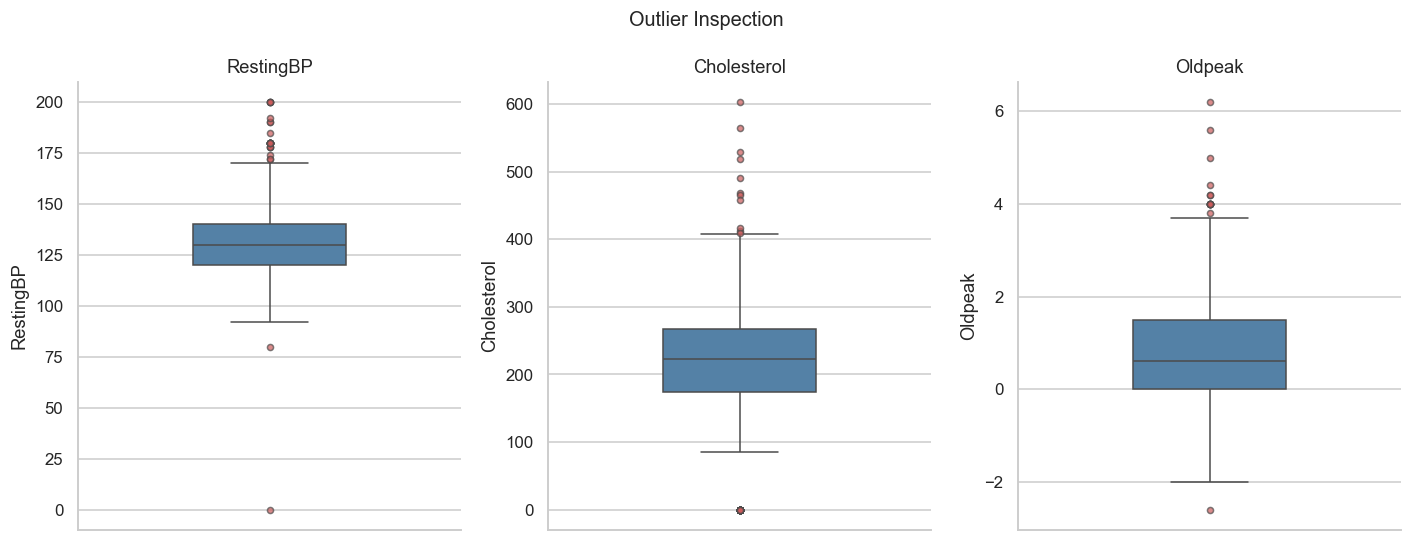

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, col in zip(axes, ['RestingBP', 'Cholesterol', 'Oldpeak']):
    sns.boxplot(y=df[col], ax=ax, color='steelblue', width=0.4,
                flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': 'indianred', 'alpha': 0.7})
    ax.set_title(col)

fig.suptitle('Outlier Inspection', fontsize=13)
plt.tight_layout()
plt.show()

In [63]:
for col in ['RestingBP', 'Cholesterol', 'Oldpeak']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    n = ((df[col] < low) | (df[col] > high)).sum()
    print(f'{col}: {n} potential outliers (IQR method) — [{low:.1f}, {high:.1f}]')

RestingBP: 28 potential outliers (IQR method) — [90.0, 170.0]
Cholesterol: 183 potential outliers (IQR method) — [32.6, 407.6]
Oldpeak: 16 potential outliers (IQR method) — [-2.2, 3.8]


Cholesterol has the most outliers by this method, the values above 500 mg/dL are pretty extreme. They could be real cases of a genetic condition called familial hypercholesterolemia (where cholesterol is just naturally very high), or they could be data entry errors. Hard to say without more clinical context. The high Oldpeak outliers are less surprising given the skewed distribution we already saw.

## Feature Engineering Suggestions

Based on everything above, here are some things worth considering before building a model:

**Encoding the categorical columns:**
- `Sex` and `ExerciseAngina` are binary so simple 0/1 mapping works fine
- `ChestPainType`, `RestingECG`, `ST_Slope` have 3-4 categories each and don't have any natural ordering, so one-hot encoding makes more sense than label encoding here

**Fixing the Cholesterol zeros:**
- 172 rows with Cholesterol = 0 can't be fed to a model as-is. The cleanest options are:
  - Replace with the median, either overall or by subgroup (sex, age group)
  - Add a separate binary column like `chol_was_missing` so the model can account for the fact that these were imputed
  - Drop those rows if we decide 746 rows is still enough to work with

**Possible new features:**
- Age grouped into bins (under 45, 45-55, 55-65, 65+) might work better than raw age since the relationship probably isn't perfectly linear
- A combined ST feature using both Oldpeak and ST_Slope together
- The one row with RestingBP = 0 should be dropped or imputed

**Scaling:**
- Numeric features are on very different scales so standardization would be needed for models like KNN or SVM. Tree-based models like random forest don't care about scale so it wouldn't matter there.

## Summary and Conclusions

So what did we actually learn from all this?

The data is mostly usable but the Cholesterol zeros are a real problem since they affect almost 1 in 5 rows. That needs to be sorted out before modeling.

Looking at which features seem to actually matter for predicting heart disease:

1. **ST_Slope** is probably the strongest single signal, flat or down slopes are very consistently associated with disease
2. **ExerciseAngina** is also very strong, if exercise causes chest pain the person is very likely to have heart disease
3. **ChestPainType** matters a lot, specifically the ASY category
4. **MaxHR** is a clean numeric separator between the two groups
5. **Oldpeak** follows a similar pattern, higher values lean toward disease
6. **Age** and **Sex** contribute but aren't as powerful on their own

Resting blood pressure didn't really separate the groups well. Cholesterol had the counterintuitive result we discussed, where the healthy group actually had higher values on average, possibly because of medication effects.

Overall the dataset is in decent shape for classification. The target isn't severely imbalanced, most features show some signal, and the main cleanup needed is the cholesterol issue. A tree-based model would probably be a reasonable first choice since it handles mixed data types well and doesn't need much preprocessing.

<br>

Learnt a lot from this course and really enjoyed working on all the Homeworks, `Thanks a lot Prof!`😊